# DockQ priority sweep

Six reconstruction weights × two DockQ weighting modes × three seeds, with dropout 0.3 and a frozen target split. This analysis uses **validation predictions only**. It compares all configurations against the matched λ=1, ordinary-MSE control, then examines score-range coverage, target variation, convergence and latent-gradient diagnostics.

Figures use LaTeX Computer Modern, large labels, full borders and no titles. Error bars and shaded bands show **sample standard deviation across three seeds**, not confidence intervals. Selecting a winner on this validation set is exploratory; a test-set improvement has not been established.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
GATE=Path.cwd() if (Path.cwd()/'dockq_priority_sweep').is_dir() else Path.cwd()/'gate_run'
ROOT=GATE/'dockq_priority_sweep'
EXPORT=GATE/'dockq_priority_analysis'; EXPORT.mkdir(exist_ok=True)
matrix=json.loads((ROOT/'matrix.json').read_text())
LAMBDAS=[0,.01,.03,.1,.3,1]; SEEDS=[7,17,27]; MODES=['none','inverse-sqrt']
MODE_LABEL={'none':'Ordinary DockQ MSE','inverse-sqrt':'Range-weighted DockQ MSE'}
EDGES=np.array([0,.2,.4,.6,.8,1.],dtype=np.float32)
BINS=['0--0.2','0.2--0.4','0.4--0.6','0.6--0.8','0.8--1.0']
mpl.rcParams.update({'text.usetex':True,'font.family':'serif','font.serif':['Computer Modern Roman'],
    'mathtext.fontset':'cm','axes.labelsize':23,'xtick.labelsize':18,'ytick.labelsize':18,
    'legend.fontsize':17,'axes.spines.top':True,'axes.spines.right':True,'axes.linewidth':1.1})
def save(fig,name):
    fig.savefig(EXPORT/(name+'.pdf'),bbox_inches='tight')
    fig.savefig(EXPORT/(name+'.png'),dpi=180,bbox_inches='tight')
    plt.show()
def rho(y,p):
    return float(spearmanr(y,p).statistic) if y.nunique()>1 and p.nunique()>1 else np.nan

## Audit the completed runs

Require all 36 distinct configurations, 50 finite training/validation epochs, identical prediction keys and labels, identical training-bin profiles, and agreement between selected-checkpoint predictions and minimum history MSE. Check validation membership against the original frozen split and confirm that the saved per-epoch reports match the histories. No model checkpoints need to be deserialized.

In [2]:
assert matrix['validation_only'] and matrix['apbs_enabled'] is False
split=json.loads((GATE/'model_extensions_10pct_quick_no_apbs'/'target_splits.json').read_text())['splits']
assert not set(split['val']['targets']) & (set(split['train']['targets'])|set(split['test']['targets']))
histories={}; predictions={}; epoch_records={}; rows=[]; target_rows=[]; bin_rows=[]
reference=None; profile_reference=None; seen=set()
for run in matrix['runs']:
    cfg=run['dockq_sweep']; key=(cfg['reconstruction_lambda'],cfg['range_weighting'],run['seed'])
    assert key not in seen; seen.add(key)
    assert cfg['dropout']==.3
    argv=run['argv']
    assert '--no-test-evaluation' in argv and argv[argv.index('--checkpoint-metric')+1]=='target_mse'
    path=ROOT/Path(run['output']).name
    assert (path/'gate_model.pt').is_file()
    h=pd.read_csv(path/'loss_history.csv')
    assert h.epoch.tolist()==list(range(1,51))
    assert np.isfinite(h.filter(regex='^(train_|val_)').to_numpy()).all()
    assert h.filter(regex='^test_').isna().all().all()
    for term,w in [('node_mse',key[0]),('edge_attr_mse',key[0]),('edge_presence_bce',.1*key[0]),('target_mse',1)]:
        assert np.allclose(h['weight_'+term],w)
    f=pd.read_csv(path/'validation_predictions.csv').sort_values(['target_id','graph_name']).reset_index(drop=True)
    assert not f.duplicated(['target_id','graph_name']).any()
    assert set(f.target_id)==set(split['val']['targets']) and len(f)==split['val']['sample_count']
    assert np.isfinite(f[['true_target','predicted_target']]).all().all()
    assert f.true_target.between(0,1).all()
    identity=f[['target_id','graph_name','true_target']]
    if reference is None: reference=identity
    else: pd.testing.assert_frame_equal(reference,identity)
    profile=json.loads((path/'dockq_training_distribution.json').read_text())
    if profile_reference is None: profile_reference=profile
    else: assert profile==profile_reference
    assert sum(profile['counts'])==split['train']['sample_count']
    records=[json.loads(line) for line in (path/'dockq_epoch_metrics.jsonl').read_text().splitlines()]
    assert [r['epoch'] for r in records]==list(range(1,51))
    assert np.allclose([r['validation']['pooled_mse'] for r in records],h.val_target_mse)
    error=f.predicted_target-f.true_target; best=h.loc[h.val_target_mse.idxmin()]
    assert np.isclose(np.mean(error**2),best.val_target_mse,rtol=1e-4,atol=1e-7)
    base=dict(lam=key[0],mode=key[1],seed=key[2],run=path.name)
    for target,g in f.groupby('target_id'):
        target_rows.append(dict(**base,target=target,n=len(g),mse=np.mean((g.predicted_target-g.true_target)**2),spearman=rho(g.true_target,g.predicted_target)))
    bindex=np.searchsorted(EDGES[1:-1],f.true_target.to_numpy(dtype=np.float32),side='right')
    for b in range(5):
        g=f.loc[bindex==b]; e=g.predicted_target-g.true_target
        bin_rows.append(dict(**base,bin=b,n=len(g),mse=np.mean(e**2),bias=e.mean(),observed=g.true_target.mean(),predicted=g.predicted_target.mean()))
    rows.append(dict(**base,mse=np.mean(error**2),best_epoch=int(best.epoch),final_mse=h.iloc[-1].val_target_mse,
        late10_mse=h.tail(10).val_target_mse.mean(),outside_range=(~f.predicted_target.between(0,1)).mean()))
    histories[key]=h; predictions[key]=f; epoch_records[key]=records
assert seen=={(l,m,s) for l in LAMBDAS for m in MODES for s in SEEDS}
per_target=pd.DataFrame(target_rows); per_bin=pd.DataFrame(bin_rows)
metrics=pd.DataFrame(rows).merge(per_target.groupby(['lam','mode','seed']).agg(macro_mse=('mse','mean'),macro_rho=('spearman','mean'),defined_rho=('spearman','count')).reset_index(),on=['lam','mode','seed'])
metrics=metrics.merge(per_bin.groupby(['lam','mode','seed']).agg(bin_mse=('mse','mean')).reset_index(),on=['lam','mode','seed'])
for name,table in [('per_run',metrics),('per_target',per_target),('per_bin',per_bin)]: table.to_csv(EXPORT/(name+'.csv'),index=False)
print(f'PASS: {len(seen)} complete runs; {len(reference)} identical validation graphs across {reference.target_id.nunique()} targets; 50 epochs each.')
display(pd.DataFrame({'DockQ bin':BINS,'training graphs':profile_reference['counts'],'candidate training weight':profile_reference['weights']}))

PASS: 36 complete runs; 1132 identical validation graphs across 10 targets; 50 epochs each.


,DockQ bin,training graphs,candidate training weight
0,0--0.2,5116,0.682196
1,0.2--0.4,1693,1.185895
2,0.4--0.6,1345,1.330496
3,0.6--0.8,1389,1.309253
4,0.8--1.0,1367,1.319746


## Which configuration improves validation DockQ MSE?

Each seed contributes equally. This sweep's λ=1 ordinary-MSE arm is the appropriate matched control; older diagnostics used a slightly different batch-average history metric. Bin-average MSE gives each occupied DockQ interval equal weight. Target-average MSE and Spearman give each target equal weight. All reported prediction metrics use the checkpoint selected by ordinary graph-average validation MSE.

In [3]:
summary=metrics.groupby(['lam','mode']).agg(n=('seed','nunique'),mean_mse=('mse','mean'),sd_mse=('mse','std'),
    macro_mse=('macro_mse','mean'),bin_mse=('bin_mse','mean'),macro_rho=('macro_rho','mean'),
    final_mse=('final_mse','mean'),best_epoch=('best_epoch','mean'))
assert summary.n.eq(3).all()
summary['improvement_pct']=100*(1-summary.mean_mse/summary.loc[(1,'none'),'mean_mse'])
summary.to_csv(EXPORT/'configuration_summary.csv')
display(summary.sort_values('mean_mse').round(5))
WINNER=summary.mean_mse.idxmin(); CONTROL=(1.,'none'); ZERO=(0.,'inverse-sqrt')
print('Validation-selected configuration:',WINNER)

n  mean_mse   sd_mse  macro_mse  bin_mse  macro_rho  \
lam  mode                                                                
1.00 inverse-sqrt  3   0.07339  0.00229    0.07159  0.09138    0.42764   
     none          3   0.07579  0.00262    0.07404  0.09264    0.43175   
0.00 inverse-sqrt  3   0.07597  0.00112    0.07331  0.09837    0.45129   
0.03 inverse-sqrt  3   0.07810  0.00307    0.07592  0.10843    0.44951   
0.30 inverse-sqrt  3   0.07811  0.00151    0.07641  0.10544    0.43729   
0.10 inverse-sqrt  3   0.07907  0.00456    0.07631  0.10713    0.43115   
0.00 none          3   0.07911  0.00343    0.07740  0.11488    0.44824   
0.30 none          3   0.08080  0.00260    0.07888  0.10886    0.41127   
0.01 inverse-sqrt  3   0.08260  0.00358    0.07991  0.11825    0.45028   
0.03 none          3   0.08390  0.00071    0.08185  0.12376    0.44502   
0.10 none          3   0.08435  0.00462    0.08173  0.12373    0.43466   
0.01 none          3   0.08518  0.00397    0.08280  0.12636    0.45329   

                   final_mse  best_epoch  improvement_pct  
lam  mode                                                  
1.00 inverse-sqrt    0.08059    19.66667          3.16811  
     none            0.08670    13.66667          0.00000  
0.00 inverse-sqrt    0.09013     5.66667         -0.24591  
0.03 inverse-sqrt    0.09773     5.33333         -3.05355  
0.30 inverse-sqrt    0.09119     6.33333         -3.06066  
0.10 inverse-sqrt    0.09524     6.00000         -4.32388  
0.00 none            0.10201     7.00000         -4.38645  
0.30 none            0.09427    13.33333         -6.61845  
0.01 inverse-sqrt    0.10261     6.33333         -8.98778  
0.03 none            0.10786     5.66667        -10.70100  
0.10 none            0.10221     5.66667        -11.29857  
0.01 none            0.10511     6.33333        -12.39796

Validation-selected configuration: (np.float64(1.0), 'inverse-sqrt')


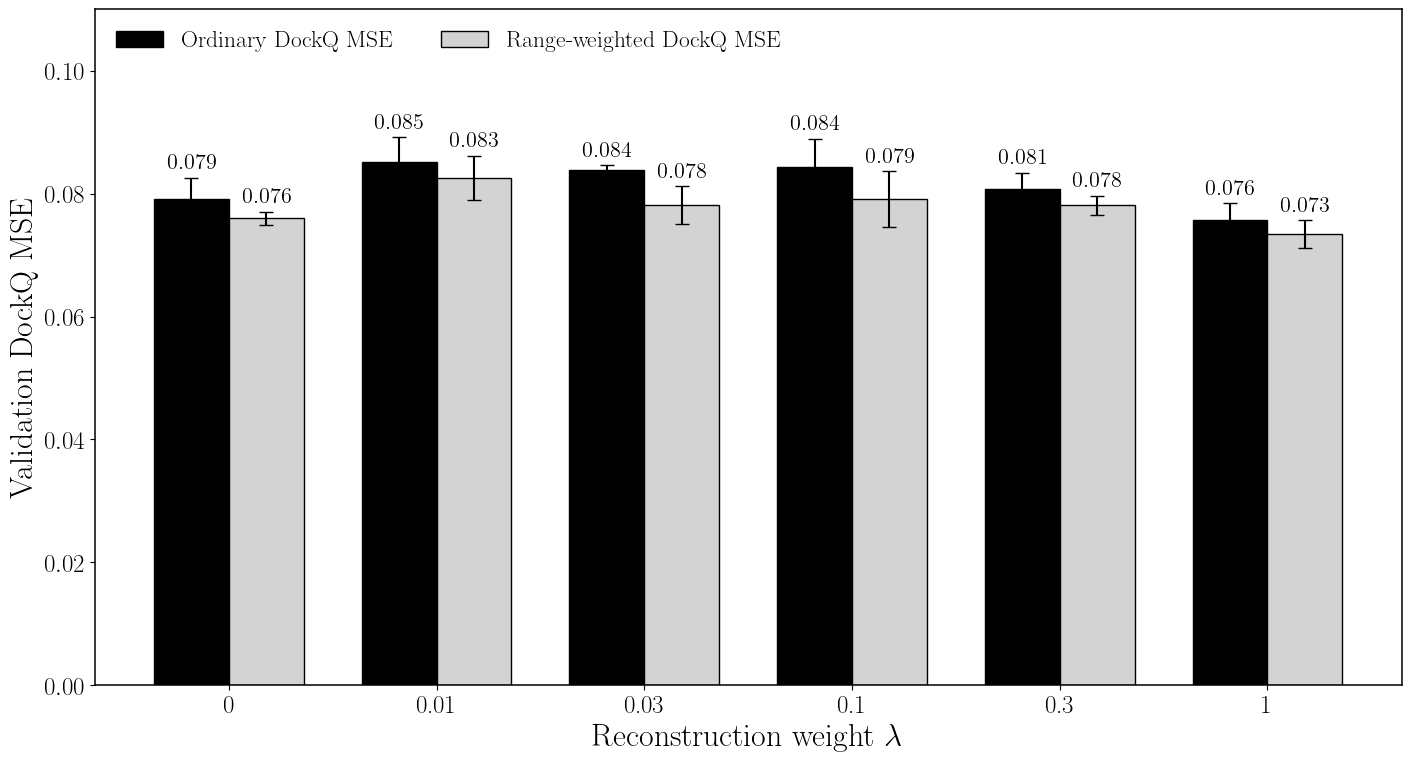

In [4]:
fig,ax=plt.subplots(figsize=(14,7.5),constrained_layout=True)
x=np.arange(len(LAMBDAS)); width=.36
for j,(mode,color) in enumerate(zip(MODES,['black','lightgray'])):
    tab=summary.xs(mode,level='mode').loc[LAMBDAS]
    positions=x+(j-.5)*width
    bars=ax.bar(positions,tab.mean_mse,width,yerr=tab.sd_mse,capsize=5,color=color,edgecolor='black',label=MODE_LABEL[mode])
    for pos,mean,sd in zip(positions,tab.mean_mse,tab.sd_mse):
        ax.text(pos,mean+sd+.0015,f'{mean:.3f}',ha='center',fontsize=16)
ax.set_xticks(x,[f'{l:g}' for l in LAMBDAS]); ax.set_xlabel(r'Reconstruction weight $\lambda$')
ax.set_ylabel('Validation DockQ MSE'); ax.set_ylim(0,.11)
ax.legend(frameon=False,ncol=2,loc='upper left')
save(fig,'validation_mse_by_lambda')

## Paired seeds: consistency and tradeoffs

Differences below are paired by training seed. Negative ΔMSE means improvement. With only three seeds and ten validation targets, these are descriptive results, not a significance claim. The selected configuration was chosen from this same table.

,seed,mse,best_epoch,final_mse,delta_control
11,7,0.07336,14,0.08197,-0.00077
23,17,0.07111,37,0.07625,-0.00331
35,27,0.07569,8,0.08355,-0.00313


,mean,min,max
lam,,,
0.00,-0.00314,-0.00631,0.00118
0.01,-0.00258,-0.00787,0.00605
0.03,-0.00580,-0.00894,-0.00290
0.10,-0.00529,-0.00595,-0.00418
0.30,-0.00270,-0.00542,-0.00121
1.00,-0.00240,-0.00331,-0.00077


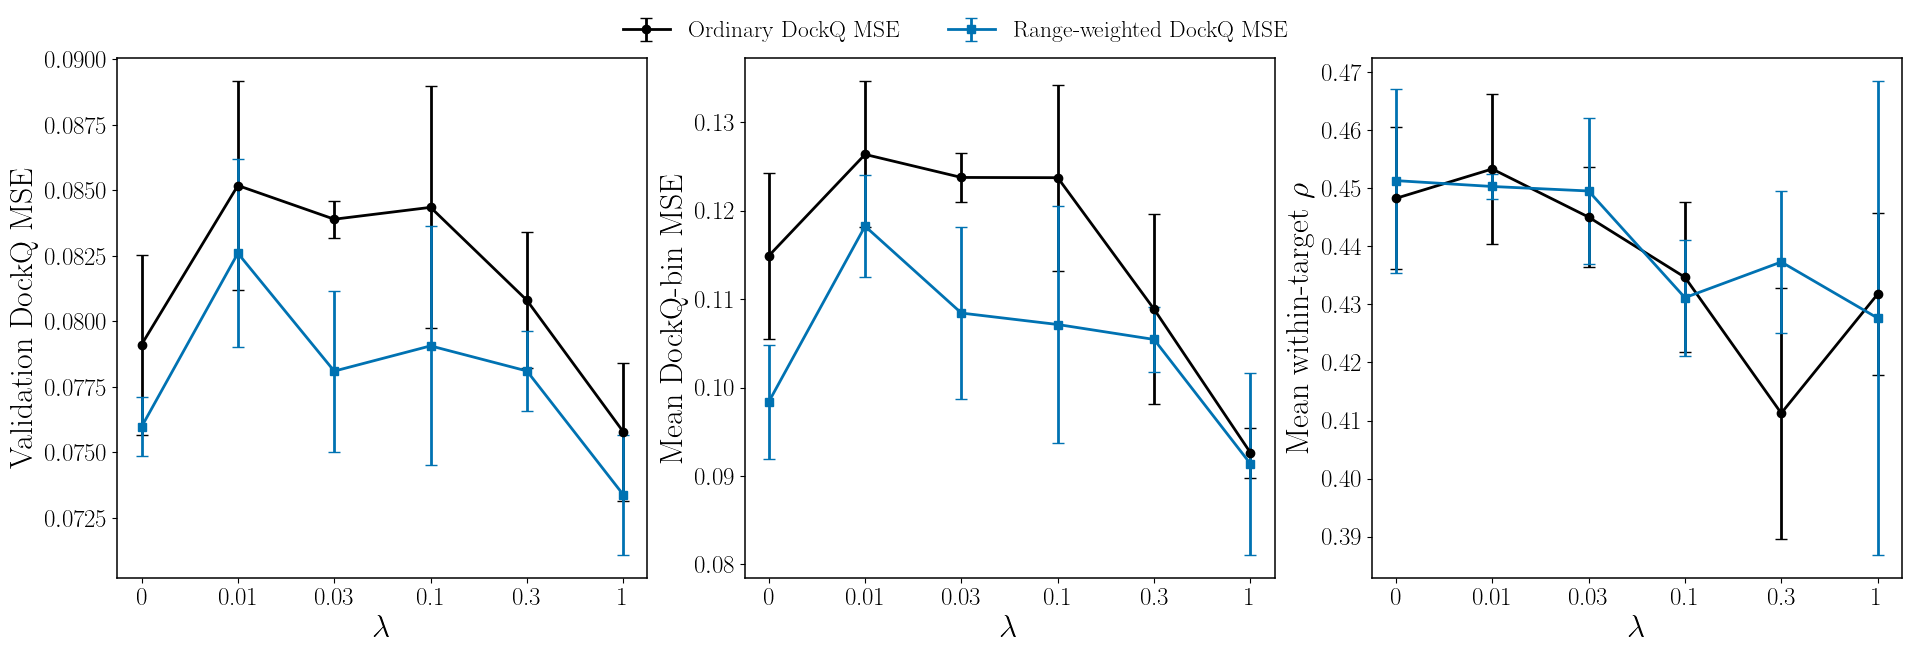

In [5]:
control=metrics.loc[(metrics.lam==CONTROL[0])&(metrics['mode']==CONTROL[1])].set_index('seed')
paired=metrics.copy()
paired['delta_control']=paired.mse-paired.seed.map(control.mse)
paired.to_csv(EXPORT/'paired_seed_deltas.csv',index=False)
weight_effect=metrics.pivot(index=['lam','seed'],columns='mode',values='mse')
weight_effect['weighted_minus_ordinary']=weight_effect['inverse-sqrt']-weight_effect['none']
weight_effect.to_csv(EXPORT/'range_weighting_effect.csv')
display(paired.loc[(paired.lam==WINNER[0])&(paired['mode']==WINNER[1]),['seed','mse','best_epoch','final_mse','delta_control']].round(5))
display(weight_effect.groupby('lam').weighted_minus_ordinary.agg(['mean','min','max']).round(5))
fig,axes=plt.subplots(1,3,figsize=(19,6.5),constrained_layout=True)
for ax,metric,ylabel in zip(axes,['mse','bin_mse','macro_rho'],['Validation DockQ MSE','Mean DockQ-bin MSE',r'Mean within-target $\rho$']):
    for mode,color,marker in [('none','black','o'),('inverse-sqrt','#0072B2','s')]:
        tab=metrics.loc[metrics['mode']==mode].groupby('lam')[metric].agg(['mean','std']).loc[LAMBDAS]
        ax.errorbar(x,tab['mean'],yerr=tab['std'],color=color,marker=marker,capsize=4,lw=2,label=MODE_LABEL[mode])
    ax.set_xticks(x,[f'{l:g}' for l in LAMBDAS]); ax.set_xlabel(r'$\lambda$'); ax.set_ylabel(ylabel)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=2,frameon=False)
save(fig,'accuracy_tradeoffs')

## Does validation improve throughout training?

Solid lines show the mean ordinary validation DockQ MSE across seeds; shading shows seed standard deviation. The left panel uses ordinary training MSE and the right panel uses range-weighted training MSE, as indicated by the in-panel text. These are epoch-wise curves, not selected-checkpoint results. Training DockQ histories are not directly compared between weighting modes because their objectives differ.

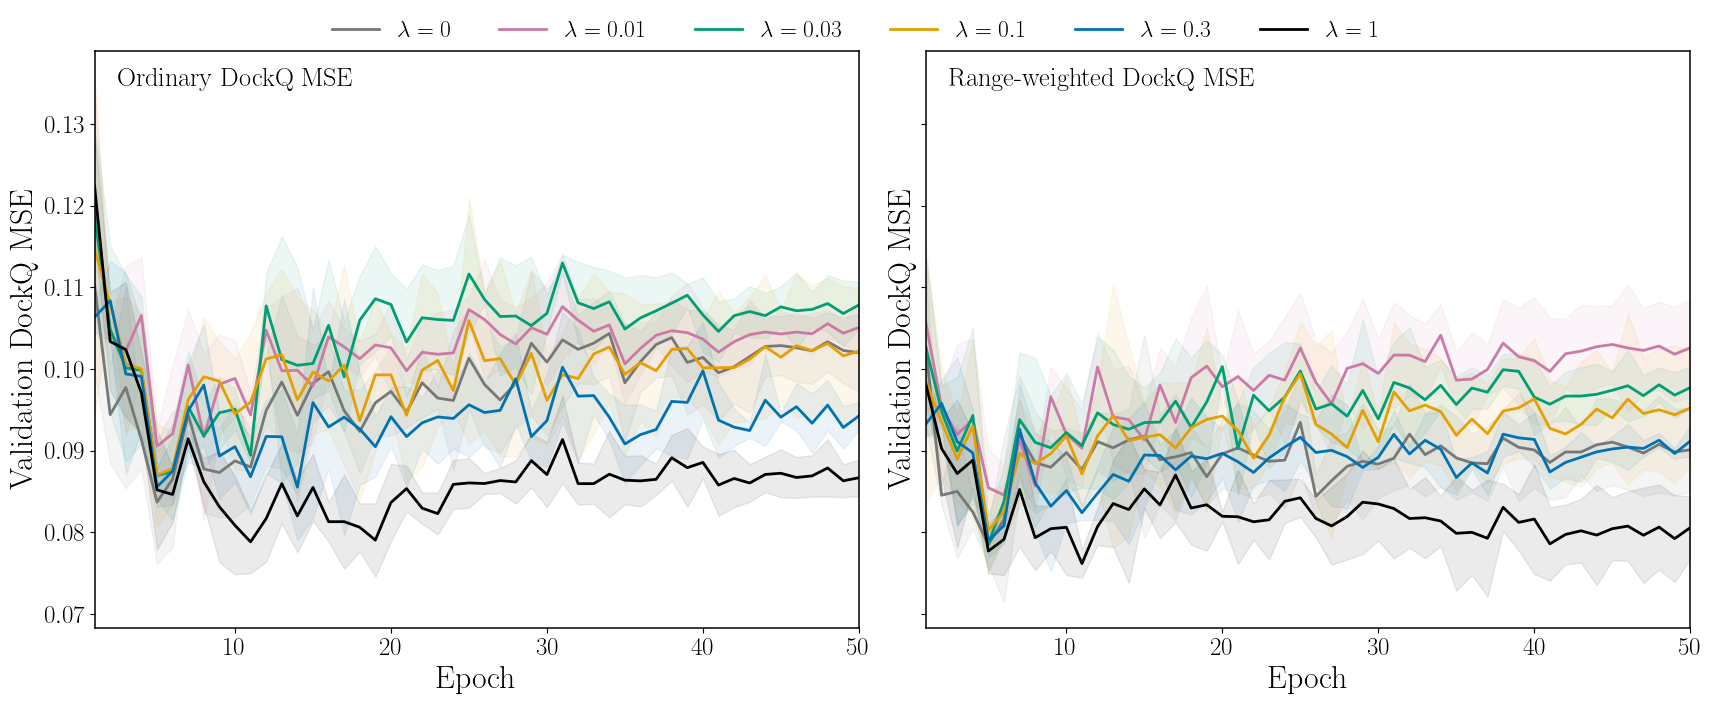

In [6]:
fig,axes=plt.subplots(1,2,figsize=(17,7),sharey=True,constrained_layout=True)
colors=['#777777','#CC79A7','#009E73','#E69F00','#0072B2','black']
for ax,mode in zip(axes,MODES):
    for l,color in zip(LAMBDAS,colors):
        a=np.array([histories[l,mode,s].val_target_mse for s in SEEDS]); mean=a.mean(0); sd=a.std(0,ddof=1)
        ax.plot(np.arange(1,51),mean,color=color,lw=2,label=rf'$\lambda={l:g}$')
        ax.fill_between(np.arange(1,51),mean-sd,mean+sd,color=color,alpha=.08)
    ax.text(.03,.97,MODE_LABEL[mode],transform=ax.transAxes,va='top',fontsize=19)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Validation DockQ MSE'); ax.set_xlim(1,50)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=6,frameon=False)
save(fig,'validation_convergence')

## Accuracy across the full DockQ range

Compare the matched control, the validation-selected configuration, and the no-reconstruction range-weighted control. Error bars show variation across seeds. Predictions should be calibrated throughout the range; merely spanning 0–1 does not demonstrate accuracy. The same validation graph counts apply to every run. Bias is predicted minus observed DockQ.

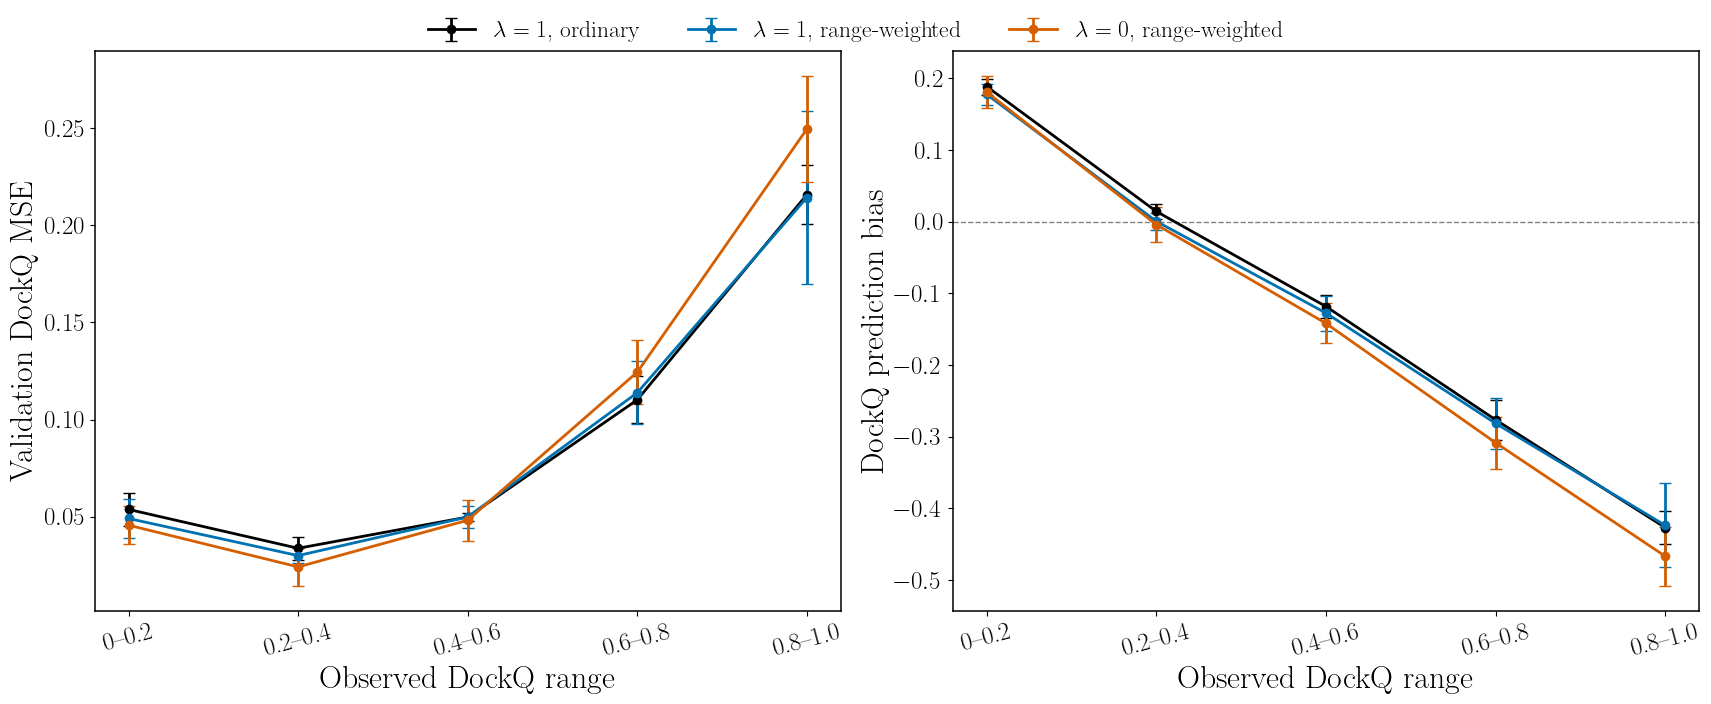

,n,mse,bias,observed,predicted,configuration
bin,,,,,,
0,539,0.0537,0.1882,0.0525,0.2407,Control
1,172,0.0337,0.0140,0.2926,0.3067,Control
2,131,0.0498,-0.1185,0.4959,0.3775,Control
3,171,0.1101,-0.2764,0.7084,0.4320,Control
4,119,0.2158,-0.4267,0.8644,0.4376,Control
0,539,0.0490,0.1772,0.0525,0.2297,Selected
1,172,0.0299,0.0002,0.2926,0.2928,Selected
2,131,0.0498,-0.1276,0.4959,0.3683,Selected
3,171,0.1138,-0.2815,0.7084,0.4269,Selected


In [7]:
SELECTED=list(dict.fromkeys([CONTROL,WINNER,ZERO]))
labels={c:rf'$\lambda={c[0]:g}$, '+('ordinary' if c[1]=='none' else 'range-weighted') for c in SELECTED}
selected_colors=['black','#0072B2','#D55E00']
fig,axes=plt.subplots(1,2,figsize=(17,7),constrained_layout=True)
for cfg,color in zip(SELECTED,selected_colors):
    f=per_bin.loc[(per_bin.lam==cfg[0])&(per_bin['mode']==cfg[1])]
    for ax,metric,ylabel in zip(axes,['mse','bias'],['Validation DockQ MSE','DockQ prediction bias']):
        tab=f.groupby('bin')[metric].agg(['mean','std'])
        ax.errorbar(np.arange(5),tab['mean'],yerr=tab['std'],color=color,marker='o',capsize=4,lw=2,label=labels[cfg])
        ax.set_xticks(np.arange(5),BINS,rotation=15); ax.set_xlabel('Observed DockQ range'); ax.set_ylabel(ylabel)
axes[1].axhline(0,color='gray',ls='--',lw=1)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=3,frameon=False)
save(fig,'dockq_range_accuracy')
range_table=per_bin.groupby(['lam','mode','bin']).agg(n=('n','first'),mse=('mse','mean'),bias=('bias','mean'),observed=('observed','mean'),predicted=('predicted','mean'))
range_table.to_csv(EXPORT/'range_summary.csv')
display(pd.concat([range_table.loc[CONTROL].assign(configuration='Control'),range_table.loc[WINNER].assign(configuration='Selected')]).round(4))

## Where does the improvement come from?

Target points compare each configuration's per-target MSE averaged across seeds. A point below the diagonal favors the selected configuration. The second panel compares mean predicted and observed DockQ in each true-score bin; it shows calibration conditional on observed score, not reliability bins based on predictions. No seed ensembling is performed.

,control_mse,selected_mse,delta
target,,,
2grn,0.12359,0.10976,-0.01383
1ugq,0.06731,0.05819,-0.00912
5by8,0.02792,0.02231,-0.00561
1j2j,0.07779,0.07430,-0.00349
2vdb,0.09761,0.09573,-0.00188
1zhi,0.09573,0.09522,-0.00051
1us7,0.03431,0.03390,-0.00041
7bxh,0.05898,0.05891,-0.00007
1ay7,0.06268,0.06403,0.00136


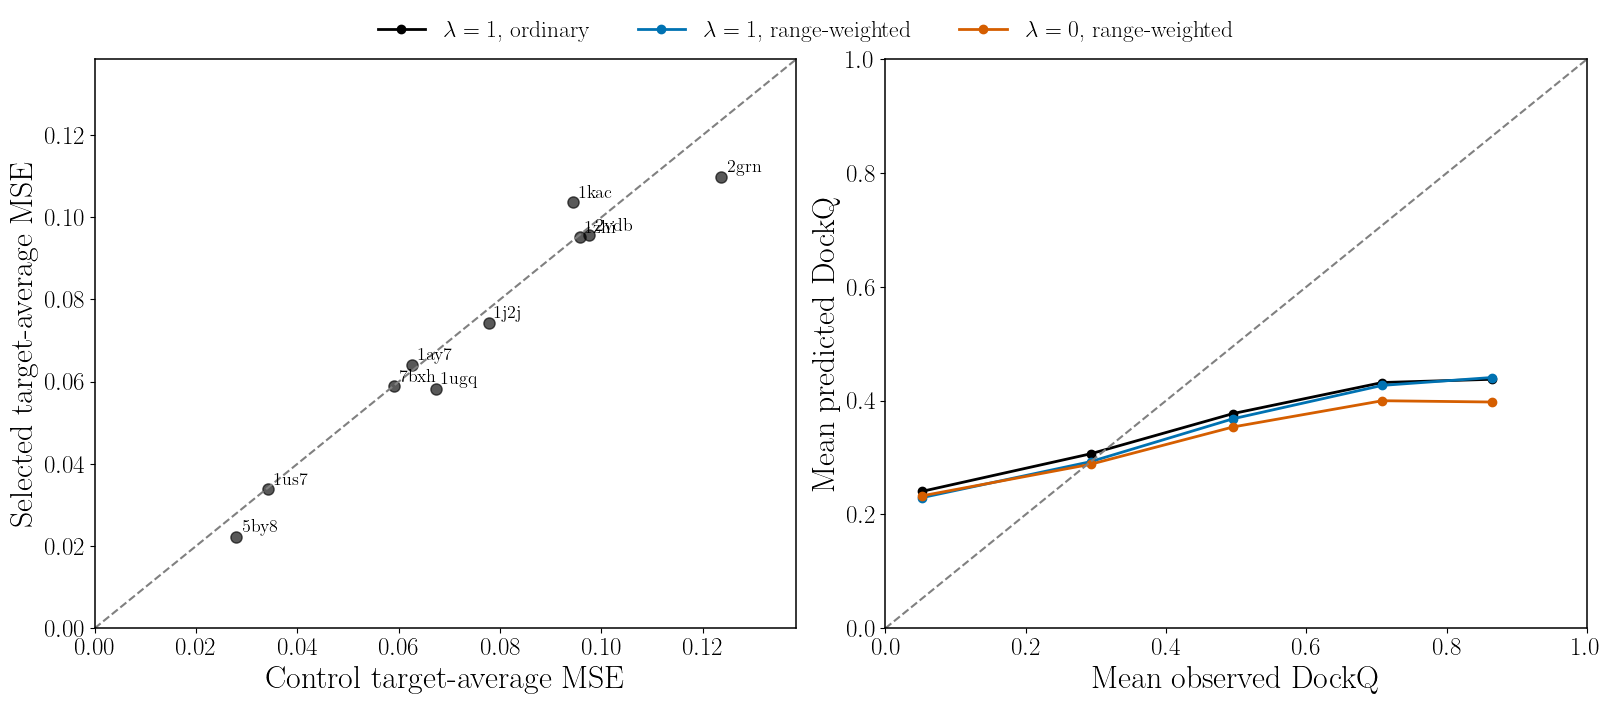

In [8]:
pt=per_target.groupby(['lam','mode','target']).mse.mean()
target_comparison=pd.DataFrame({'control_mse':pt.loc[CONTROL],'selected_mse':pt.loc[WINNER]})
target_comparison['delta']=target_comparison.selected_mse-target_comparison.control_mse
target_comparison.to_csv(EXPORT/'target_comparison.csv')
display(target_comparison.sort_values('delta').round(5))
fig,axes=plt.subplots(1,2,figsize=(16,7),constrained_layout=True)
ax=axes[0]; ax.scatter(target_comparison.control_mse,target_comparison.selected_mse,c='black',alpha=.65,s=65)
lim=target_comparison[['control_mse','selected_mse']].to_numpy().max()*1.12
ax.plot([0,lim],[0,lim],ls='--',color='gray'); ax.set_xlim(0,lim); ax.set_ylim(0,lim)
ax.set_xlabel('Control target-average MSE'); ax.set_ylabel('Selected target-average MSE')
for target,row in target_comparison.iterrows(): ax.annotate(target,(row.control_mse,row.selected_mse),xytext=(4,3),textcoords='offset points',fontsize=13)
for cfg,color in zip(SELECTED,selected_colors):
    tab=range_table.loc[cfg]; axes[1].plot(tab.observed,tab.predicted,'o-',color=color,lw=2,label=labels[cfg])
axes[1].plot([0,1],[0,1],ls='--',color='gray'); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)
axes[1].set_xlabel('Mean observed DockQ'); axes[1].set_ylabel('Mean predicted DockQ')
fig.legend(*axes[1].get_legend_handles_labels(),loc='outside upper center',ncol=3,frameon=False)
save(fig,'target_and_range_calibration')

## Structural versus DockQ gradient diagnostics

These measurements are the weighted objective gradient norms at shared node embeddings on the **first training batch of each epoch**. They are not full-epoch encoder-parameter gradient norms, and ratios do not measure gradient alignment or prove causality. Zero reconstruction weight gives exactly zero reconstruction gradients. The numerical loss scale alone should not be interpreted as evidence that reconstruction is harmful.

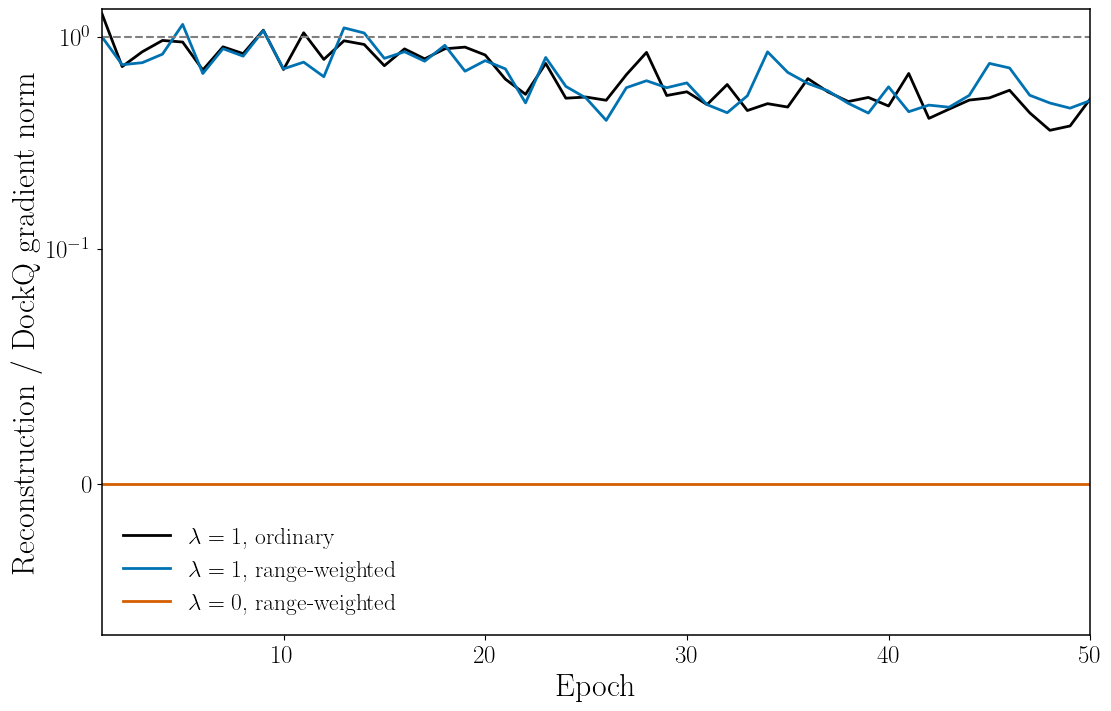

In [9]:
grad_rows=[]
for (l,m,s),records in epoch_records.items():
    for r in records:
        g=r['first_train_batch_gradients']
        assert np.isfinite([g['gradient_dockq'],g['gradient_structure']]).all()
        if l==0: assert g['gradient_structure']==0
        grad_rows.append(dict(lam=l,mode=m,seed=s,epoch=r['epoch'],dockq=g['gradient_dockq'],structure=g['gradient_structure']))
grad=pd.DataFrame(grad_rows); grad['ratio']=grad.structure/grad.dockq.replace(0,np.nan)
grad.to_csv(EXPORT/'latent_gradient_diagnostics.csv',index=False)
fig,ax=plt.subplots(figsize=(11,7),constrained_layout=True)
for cfg,color in zip(SELECTED,selected_colors):
    f=grad.loc[(grad.lam==cfg[0])&(grad['mode']==cfg[1])].groupby('epoch').ratio.mean()
    ax.plot(f.index,f,color=color,lw=2,label=labels[cfg])
ax.axhline(1,color='gray',ls='--'); ax.set_xlabel('Epoch'); ax.set_ylabel('Reconstruction / DockQ gradient norm')
ax.set_yscale('symlog',linthresh=.1); ax.set_xlim(1,50)
ax.legend(frameon=False); save(fig,'latent_gradient_ratio')

## Readout and next experiment

The text below is generated from the downloaded results. Ranking configurations by mean validation MSE does not establish statistical significance or test generalization. The three seeds share one validation split; ten targets limit how precisely we can assess target-to-target generalization. Follow-up validation on additional target splits would help distinguish a robust effect from this split's idiosyncrasies. Keep the test set sealed until the evaluation protocol is fixed.

In [10]:
w=summary.loc[WINNER]; c=summary.loc[CONTROL]
p=paired.loc[(paired.lam==WINNER[0])&(paired['mode']==WINNER[1])]
weighted_means=weight_effect.groupby('lam').weighted_minus_ordinary.mean()
low=range_table.loc[(*WINNER,0)]; high=range_table.loc[(*WINNER,4)]
lines=[f'All 36 runs completed 50 epochs; {len(reference)} validation graphs across {reference.target_id.nunique()} targets.',
 f'Best mean validation MSE: lambda={WINNER[0]:g}, weighting={WINNER[1]}: {w.mean_mse:.5f} +/- {w.sd_mse:.5f} (seed SD).',
 f'Matched lambda=1 ordinary-MSE control: {c.mean_mse:.5f} +/- {c.sd_mse:.5f}; relative improvement {w.improvement_pct:.2f}%.',
 f'Selected configuration improves MSE in {int((p.delta_control<0).sum())}/3 paired seeds and {int((target_comparison.delta<0).sum())}/{len(target_comparison)} targets (target MSE averaged across seeds).',
 f'Range weighting lowers mean validation MSE at {int((weighted_means<0).sum())}/6 lambda values.',
 f'Selected mean final-epoch MSE is {w.final_mse:.5f}; mean selected epoch is {w.best_epoch:.1f}.',
 f'For true DockQ 0-0.2: mean observed {low.observed:.3f}, predicted {low.predicted:.3f}. For 0.8-1.0: observed {high.observed:.3f}, predicted {high.predicted:.3f}.',
 'The score-range compression is not eliminated; inspect the bin errors and biases before claiming full-range accuracy.',
 'This sweep does not support reducing reconstruction weight as a general fix. Preserve the lambda=1 range-weighted configuration as the leading candidate and confirm on additional target splits before adding complexity.']
readout='\n\n'.join(lines)
(EXPORT/'readout.md').write_text(readout+'\n'); display(Markdown(readout))

All 36 runs completed 50 epochs; 1132 validation graphs across 10 targets.

Best mean validation MSE: lambda=1, weighting=inverse-sqrt: 0.07339 +/- 0.00229 (seed SD).

Matched lambda=1 ordinary-MSE control: 0.07579 +/- 0.00262; relative improvement 3.17%.

Selected configuration improves MSE in 3/3 paired seeds and 8/10 targets (target MSE averaged across seeds).

Range weighting lowers mean validation MSE at 6/6 lambda values.

Selected mean final-epoch MSE is 0.08059; mean selected epoch is 19.7.

For true DockQ 0-0.2: mean observed 0.053, predicted 0.230. For 0.8-1.0: observed 0.864, predicted 0.441.

The score-range compression is not eliminated; inspect the bin errors and biases before claiming full-range accuracy.

This sweep does not support reducing reconstruction weight as a general fix. Preserve the lambda=1 range-weighted configuration as the leading candidate and confirm on additional target splits before adding complexity.

## Which DockQ ranges explain the pooled-MSE gain?

Multiply each bin's control-minus-selected MSE by its fraction of validation graphs. Positive contributions improve pooled MSE; negative contributions offset gains elsewhere. This decomposes the observed difference, not a causal effect of weighting.

In [2]:
contribution=range_table.loc[CONTROL][["n","mse"]].rename(columns={"mse":"control_mse"}).copy()
contribution["selected_mse"]=range_table.loc[WINNER,"mse"]
contribution["contribution_to_mse_improvement"]=(contribution.control_mse-contribution.selected_mse)*contribution.n/contribution.n.sum()
assert np.isclose(contribution.contribution_to_mse_improvement.sum(),summary.loc[CONTROL,"mean_mse"]-summary.loc[WINNER,"mean_mse"])
contribution.to_csv(EXPORT/"mse_improvement_by_bin.csv")
display(contribution.round(6))
low_share=100*contribution.loc[0,"contribution_to_mse_improvement"]/contribution.contribution_to_mse_improvement.sum()
statement=f"The 0–0.2 bin accounts for {low_share:.1f}% of the net pooled-MSE improvement. The gain is therefore largely at low DockQ; the high-score underprediction remains essentially unresolved."
display(Markdown(statement))
with (EXPORT/"readout.md").open("a") as handle: handle.write("\n"+statement+"\n")


,n,control_mse,selected_mse,contribution_to_mse_improvement
bin,,,,
0,539,0.053716,0.049043,0.002225
1,172,0.033692,0.029928,0.000572
2,131,0.049803,0.049816,-0.000002
3,171,0.110144,0.113814,-0.000554
4,119,0.215845,0.214323,0.000160


The 0–0.2 bin accounts for 92.7% of the net pooled-MSE improvement. The gain is therefore largely at low DockQ; the high-score underprediction remains essentially unresolved.